# 08 — Summary & Research Questions
### Mục 0.4 — Hình thành giả thuyết nghiên cứu & Tổng kết Giai đoạn 0

**Mục đích**: tổng hợp kết quả từ 7 notebook trước, xác nhận Giai đoạn 0
đã hoàn chỉnh, và trình bày lại 5 câu hỏi nghiên cứu (RQ1–RQ5) cùng giả
thuyết tương ứng (H1–H5) — cầu nối chuyển sang thiết kế pipeline chính
thức ở Giai đoạn 1–4.

Notebook này **không tạo phân tích mới** — chỉ tổng hợp lại output đã lưu
từ các notebook 01–07. Nếu có ô báo lỗi "không tìm thấy file", quay lại
chạy notebook tương ứng trước.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import Image, display
from common import pipeline
pd.set_option("display.max_colwidth", 120)

In [2]:
# ============================== CẤU HÌNH ==============================
# Đổi USE_SYNTHETIC_DATA = False và chỉnh REAL_DATA_ROOT khi đã có dữ liệu
# CWRU thật. Xem README.md phần "Chuyển sang dữ liệu thật".
USE_SYNTHETIC_DATA = True
REAL_DATA_ROOT = Path("../../data/raw")            # <-- de_tai_nckh/data/raw/
SYNTHETIC_DATA_ROOT = Path("./_data/synthetic_cwru")
OUTPUT_DIR = Path("./outputs")
FORCE_REBUILD_MANIFEST = False
# ========================================================================

In [3]:
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Tổng quan manifest

In [4]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=False,   # dùng lại manifest đã build ở notebook 01
)

n_total = len(manifest)
n_warn = int(manifest["has_warning"].sum())
print(f"Tổng số file trong manifest : {n_total}")
print(f"Số file có cảnh báo         : {n_warn} ({n_warn/max(n_total,1)*100:.1f}%)")

print("\nSố file theo (nhãn x tải):")
print(manifest.pivot_table(index="label", columns="load_hp", values="file_path", aggfunc="count", fill_value=0))

Tổng số file trong manifest : 40
Số file có cảnh báo         : 0 (0.0%)

Số file theo (nhãn x tải):
load_hp  0  1  2  3
label              
B        3  3  3  3
IR       3  3  3  3
Normal   1  1  1  1
OR       3  3  3  3


In [5]:
# Đếm số lần xuất hiện theo LOẠI cảnh báo (parse từ cột warnings)
warning_keywords = [
    "NGHI_NGO_SAMPLING_RATE", "THOI_LUONG_BAT_THUONG", "RPM_LECH",
    "VONG_BI_NTN", "DUONG_KINH_LA", "OR_THIEU_VI_TRI", "OR_NGOAI_PHAM_VI",
    "THIEU_NHAN", "THIEU_TAI",
]
all_warnings_text = " ".join(manifest["warnings"].fillna("").tolist())
counts = {kw: all_warnings_text.count(kw) for kw in warning_keywords}
counts_df = pd.Series(counts, name="so_lan_xuat_hien").sort_values(ascending=False)
counts_df.to_csv(TABLES_DIR / "08_warning_counts_summary.csv")
counts_df[counts_df > 0]

Series([], Name: so_lan_xuat_hien, dtype: int64)

## 2. Các hình minh chứng đã tạo (notebook 02–05, 07)

--- So sánh dạng sóng thời gian (notebook 02) ---


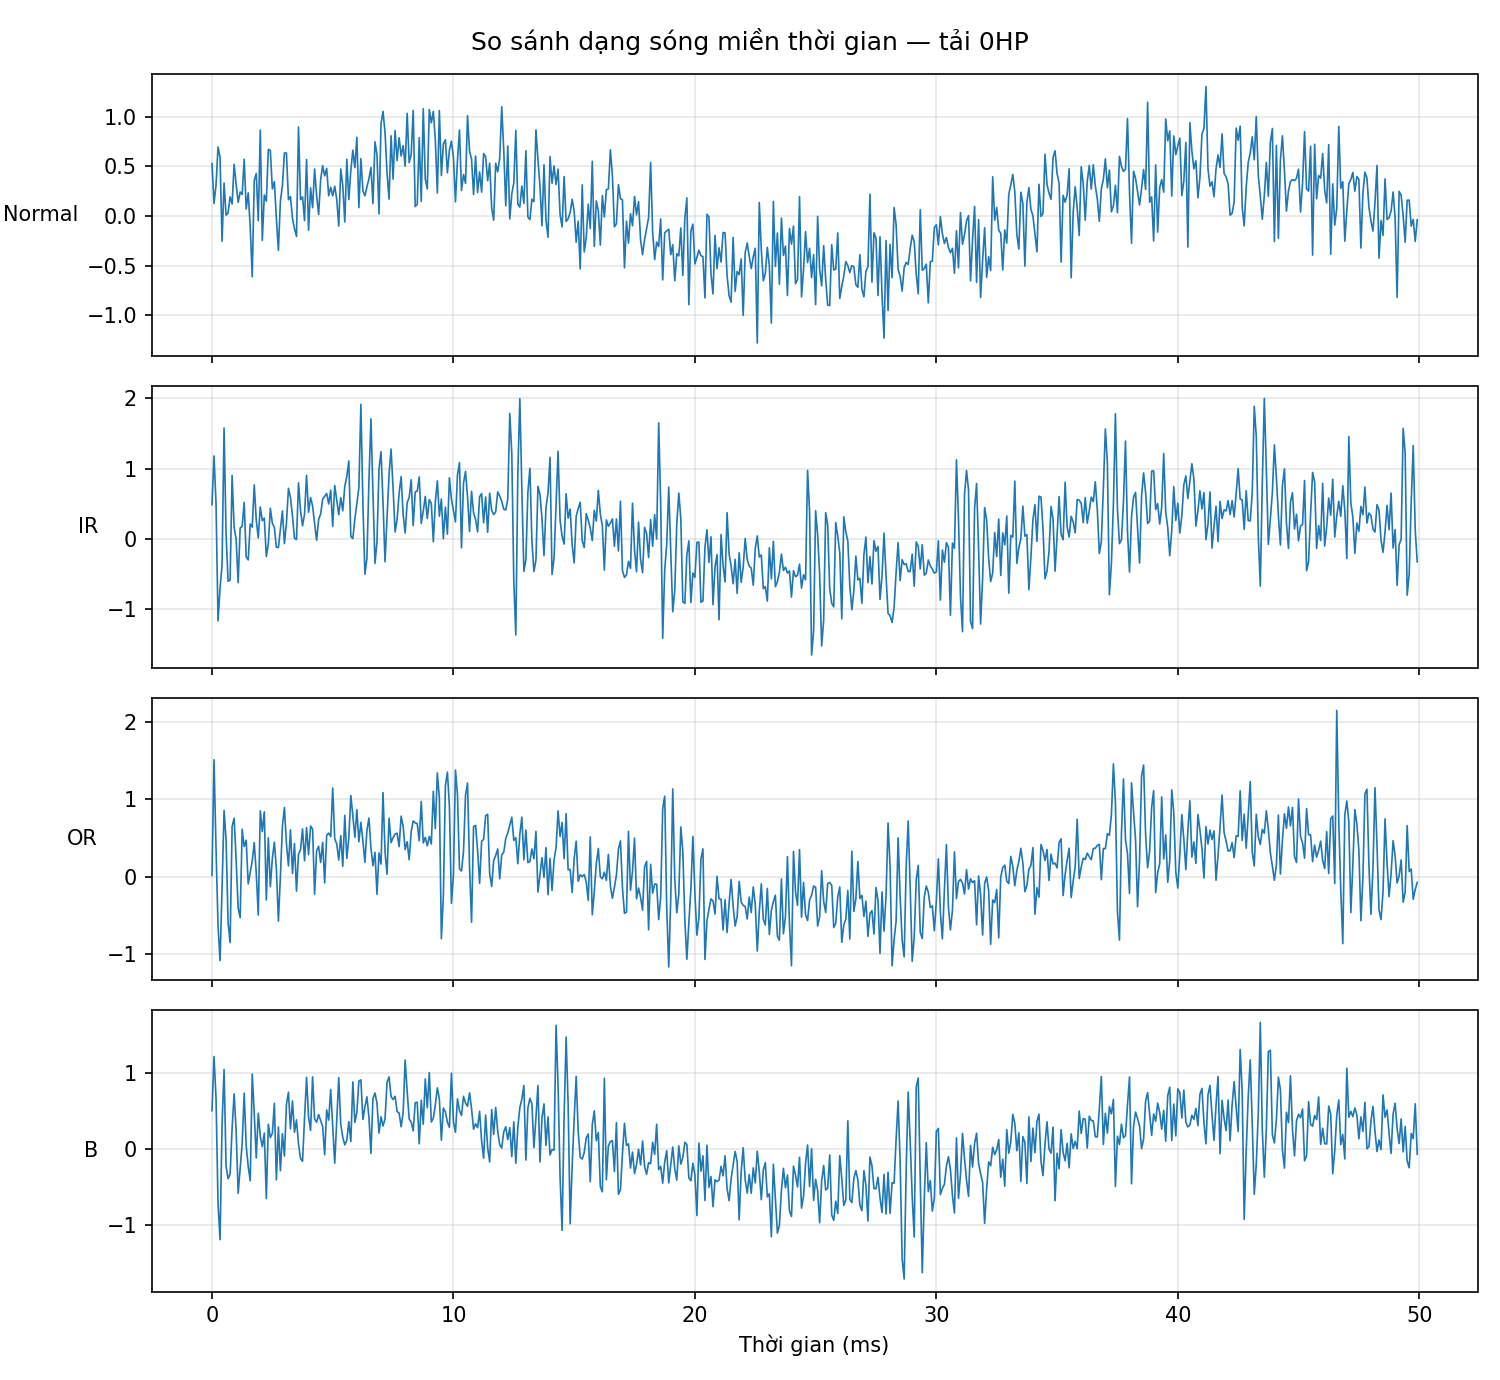


--- FFT trục Hz qua các tải (notebook 03) ---


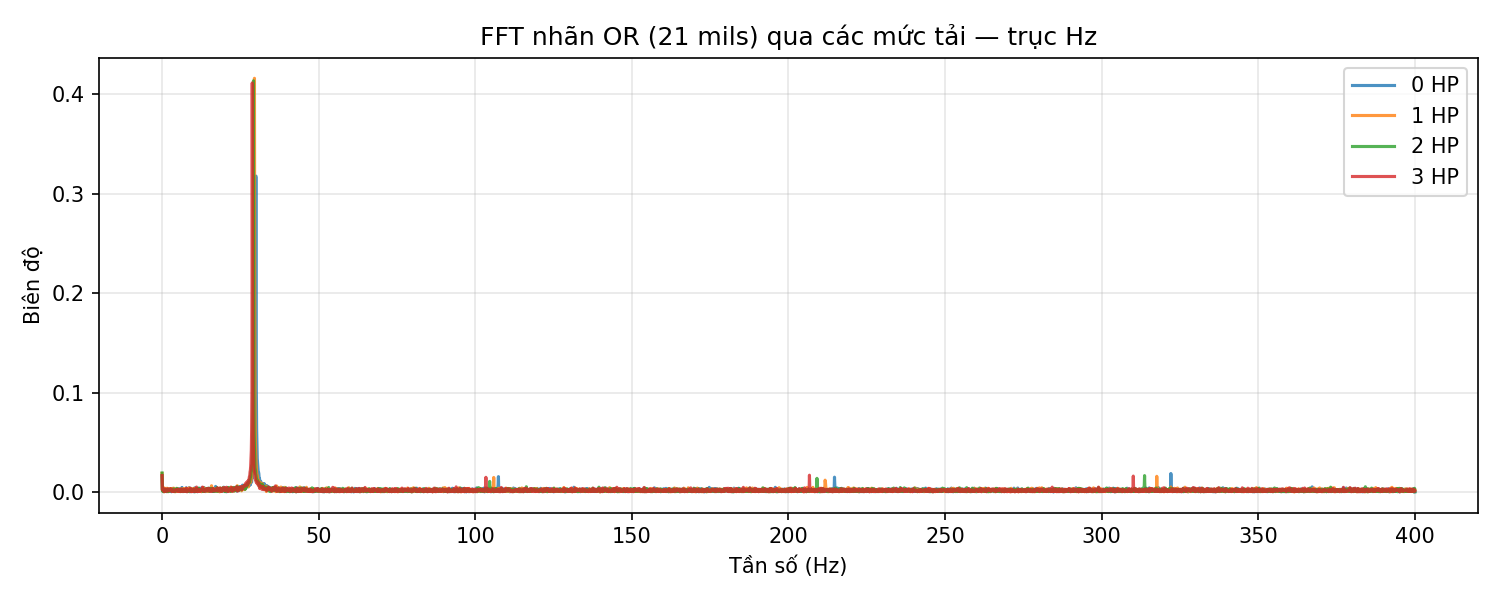


--- Phổ Order qua các tải (notebook 04) ---


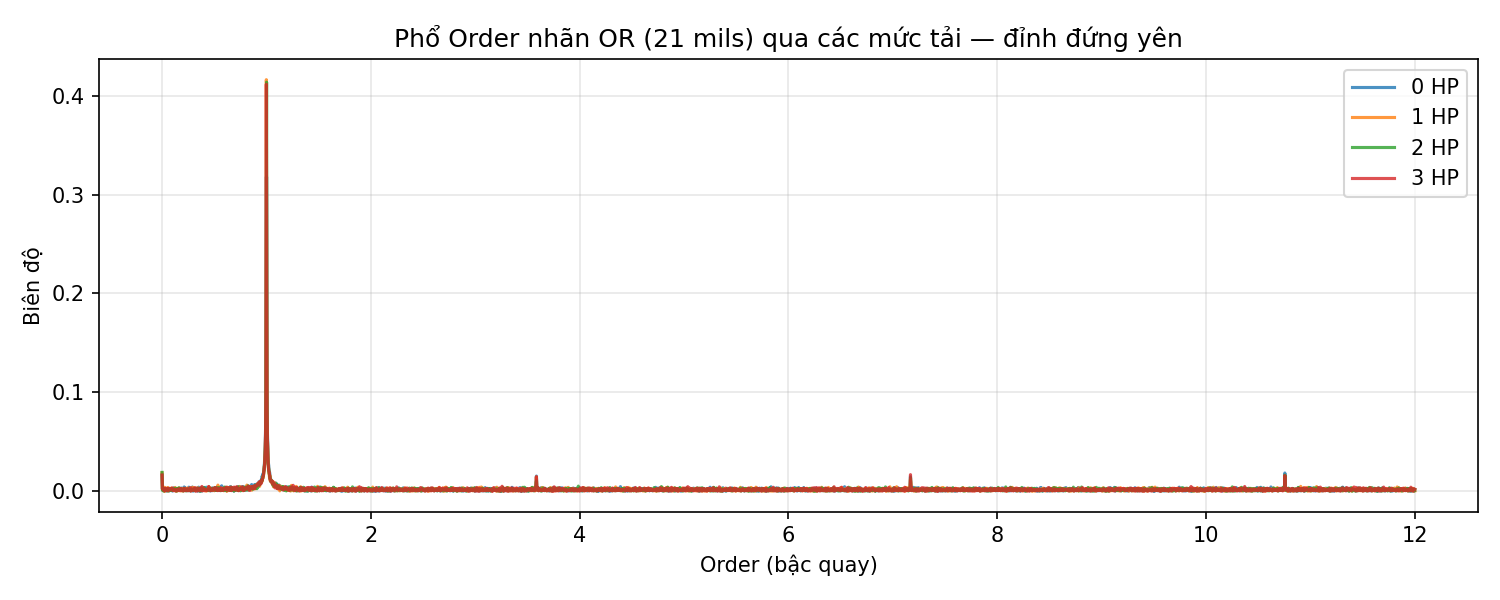


--- Phổ Envelope Square-Law (notebook 05) ---


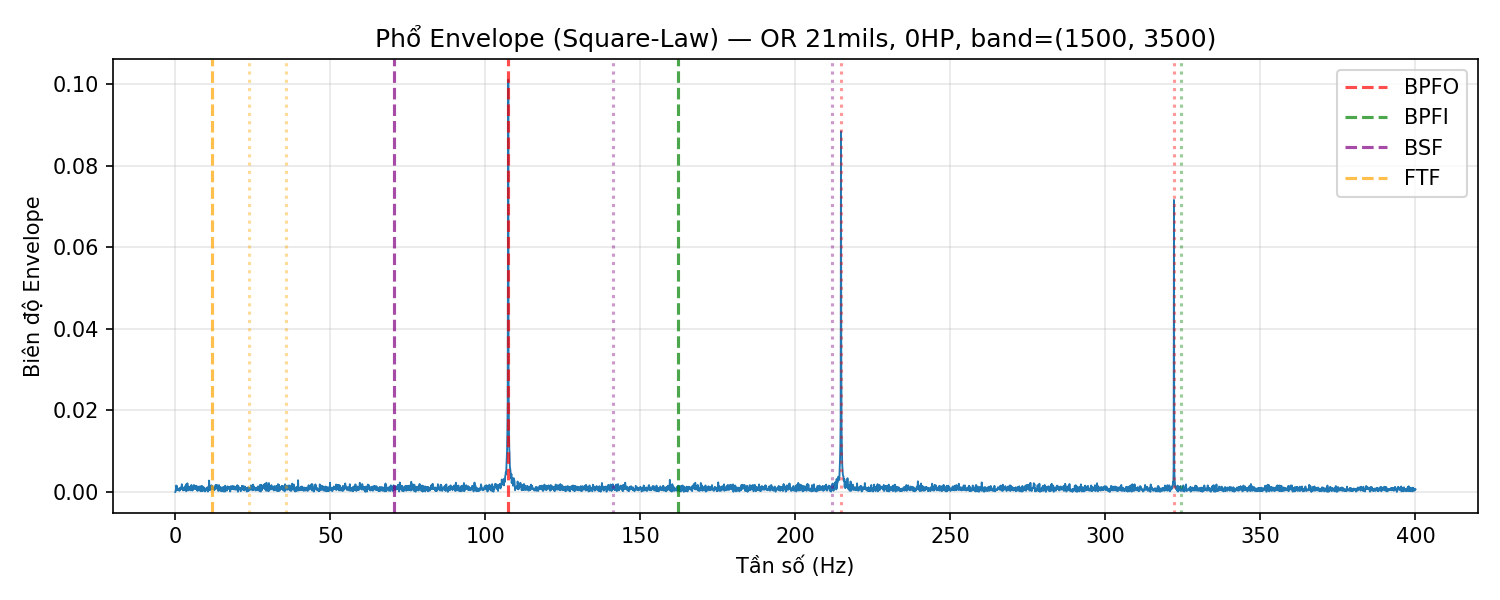


--- Cấu trúc 4-fold LOLO (notebook 07) ---


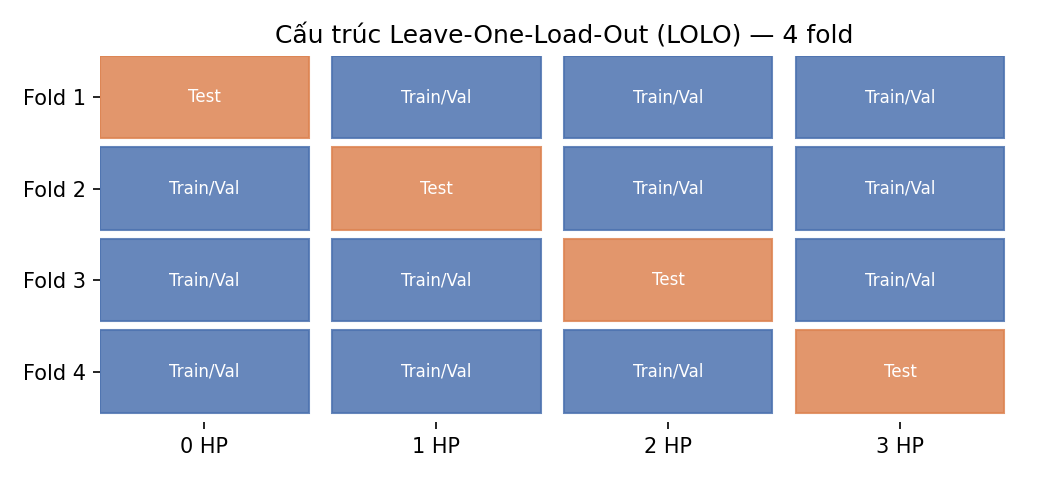

In [6]:
figure_files = [
    ("02_time_domain_comparison.png", "So sánh dạng sóng thời gian (notebook 02)"),
    ("03_fft_hz_across_loads.png", "FFT trục Hz qua các tải (notebook 03)"),
    ("04_order_domain_across_loads.png", "Phổ Order qua các tải (notebook 04)"),
    ("05_envelope_spectrum_square_law.png", "Phổ Envelope Square-Law (notebook 05)"),
    ("07_lolo_structure.png", "Cấu trúc 4-fold LOLO (notebook 07)"),
]

for fname, caption in figure_files:
    fpath = FIGURES_DIR / fname
    print(f"--- {caption} ---")
    if fpath.exists():
        display(Image(filename=str(fpath)))
    else:
        print(f"  [chưa có — chạy notebook tương ứng trước] {fpath}")
    print()

## 3. Research Questions & Hypotheses

Bảng dưới đây trình bày lại 5 câu hỏi nghiên cứu chính thức của đề tài —
hình thành từ quan sát thực nghiệm ở notebook 01–07.

| RQ | Nội dung | Giả thuyết (H) | Thực nghiệm | Notebook liên quan |
|---|---|---|---|---|
| **RQ1** | Chênh lệch accuracy giữa Random Window Split và File-based Split + LOLO trên CWRU là bao nhiêu? | **H1**: Random Window Split cho accuracy cao hơn đáng kể (ảo) do rò rỉ dữ liệu | Bảng 1 (Giai đoạn 4) | 06 (sơ bộ) |
| **RQ2** | MLP trên đặc trưng chọn lọc (Order + Envelope) có đạt/vượt CNN1D học trực tiếp từ tín hiệu thô không? | **H2**: MLP cạnh tranh được với CNN1D, ổn định hơn qua các fold LOLO (CNN1D dễ overfit hơn trên tập nhỏ) | Giai đoạn 2.3 | 07 (cấu trúc LOLO dùng chung) |
| **RQ3** | Rút gọn ~30 đặc trưng ảnh hưởng thế nào đến accuracy và RAM/MACC? | **H3**: RAM/MACC giảm đáng kể, accuracy giảm không đáng kể (có thể tăng nhẹ) | Bảng 2 (Giai đoạn 4) | — (Giai đoạn 2.2) |
| **RQ4** | Square-Law Demodulation tiết kiệm bao nhiêu thời gian/RAM so với Hilbert Transform trên ARM Cortex-M? | **H4**: Nhanh hơn và nhẹ RAM hơn đáng kể (không cần FFT/IFFT, buffer số phức) | Bảng 3a (Giai đoạn 4) | 05 (kiểm tra chéo hình dạng phổ) |
| **RQ5** | Goertzel có lợi cả tốc độ lẫn RAM so với FFT toàn dải, hay chỉ một trong hai? | **H5**: Nếu M > log₂(N), chỉ lợi RAM, không chắc lợi tốc độ | Bảng 3b (Giai đoạn 4) | — (Giai đoạn 3) |

*(RQ4, RQ5 đo tài nguyên **thật** qua STM32Cube.AI / ST Edge AI Cloud —
notebook 05 chỉ kiểm tra chéo hình dạng phổ, không đo tài nguyên.)*

## 4. Checklist trước khi chuyển sang Giai đoạn 1

- [ ] Đã chỉnh `parse_metadata_from_filename()` khớp đúng với dữ liệu thật
      (notebook 01), xác nhận bằng cách so ngẫu nhiên vài dòng manifest với
      bảng tra cứu gốc trên trang CWRU.
- [ ] Đã đọc hết cảnh báo trong `outputs/tables/01_warnings.csv`, quyết
      định rõ giữ/loại từng trường hợp (đặc biệt: file 28/40 mils dùng
      NTN, vị trí OR ngoài Centered, file Normal sai sampling rate).
- [ ] Đã chọn xong `BAND_HZ` cho Square-Law Demodulation dựa trên quan sát
      phổ thật ở notebook 03/05 (không dùng giá trị mặc định trong code mẫu).
- [ ] Đã lưu các hình notebook 02–05, 07 để dùng trực tiếp trong phần Cơ sở
      lý thuyết của báo cáo.
- [ ] Đã chạy notebook 06 bằng dữ liệu **thật** (không chỉ giả lập), có
      ΔAccuracy sơ bộ thật để đối chiếu với kết quả chính thức ở Giai đoạn 4.
- [ ] Đã kiểm tra độ cân bằng file giữa các tải (notebook 07) và ghi chú
      nếu có lệch đáng kể.

## 5. Kết luận Giai đoạn 0

Toàn bộ quyết định thiết kế của Giai đoạn 1–4 (phạm vi dữ liệu, dải
bandpass, cấu trúc LOLO, 5 câu hỏi nghiên cứu) đều bắt nguồn từ quan sát
thực nghiệm trong 7 notebook trên — không phải giả định trước. Khi checklist
ở mục 4 đã hoàn tất, dữ liệu và pipeline đã sẵn sàng cho Giai đoạn 1.